In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BACKGROUND = "#141414"
NETFLIX_RED = "#E50914"
TEXT = "#F5F5F1"

plt.style.use("dark_background")

sns.set_theme(
    style="darkgrid",
    context="talk"
)

plt.rcParams["figure.facecolor"] = BACKGROUND
plt.rcParams["axes.facecolor"] = BACKGROUND
plt.rcParams["savefig.facecolor"] = BACKGROUND
plt.rcParams["text.color"] = TEXT
plt.rcParams["axes.labelcolor"] = TEXT
plt.rcParams["xtick.color"] = TEXT
plt.rcParams["ytick.color"] = TEXT

In [20]:
df = pd.read_csv(r"C:\Users\Sarvesh Mishra\OneDrive\Desktop\netflix_analysis\netflix_titles.csv")

print(df.shape)

df.head()

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [21]:
df.drop_duplicates(inplace=True)

df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")

df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

C:\Users\Sarvesh Mishra\AppData\Local\Temp\ipykernel_18152\118363639.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


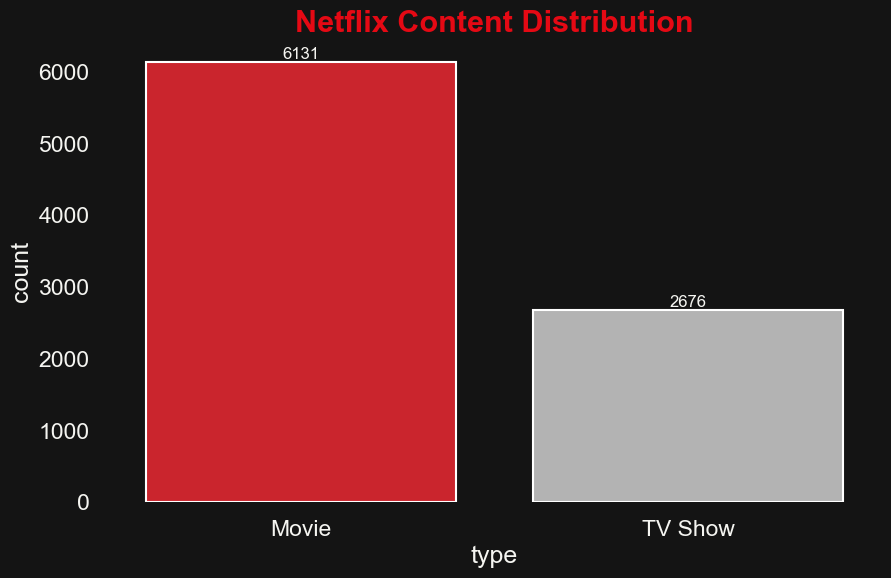

In [22]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    x="type",
    data=df,
    palette=[NETFLIX_RED, "#B3B3B3"]
)

plt.title(
    "Netflix Content Distribution",
    fontsize=22,
    fontweight="bold",
    color=NETFLIX_RED
)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

C:\Users\Sarvesh Mishra\AppData\Local\Temp\ipykernel_18152\1088503601.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


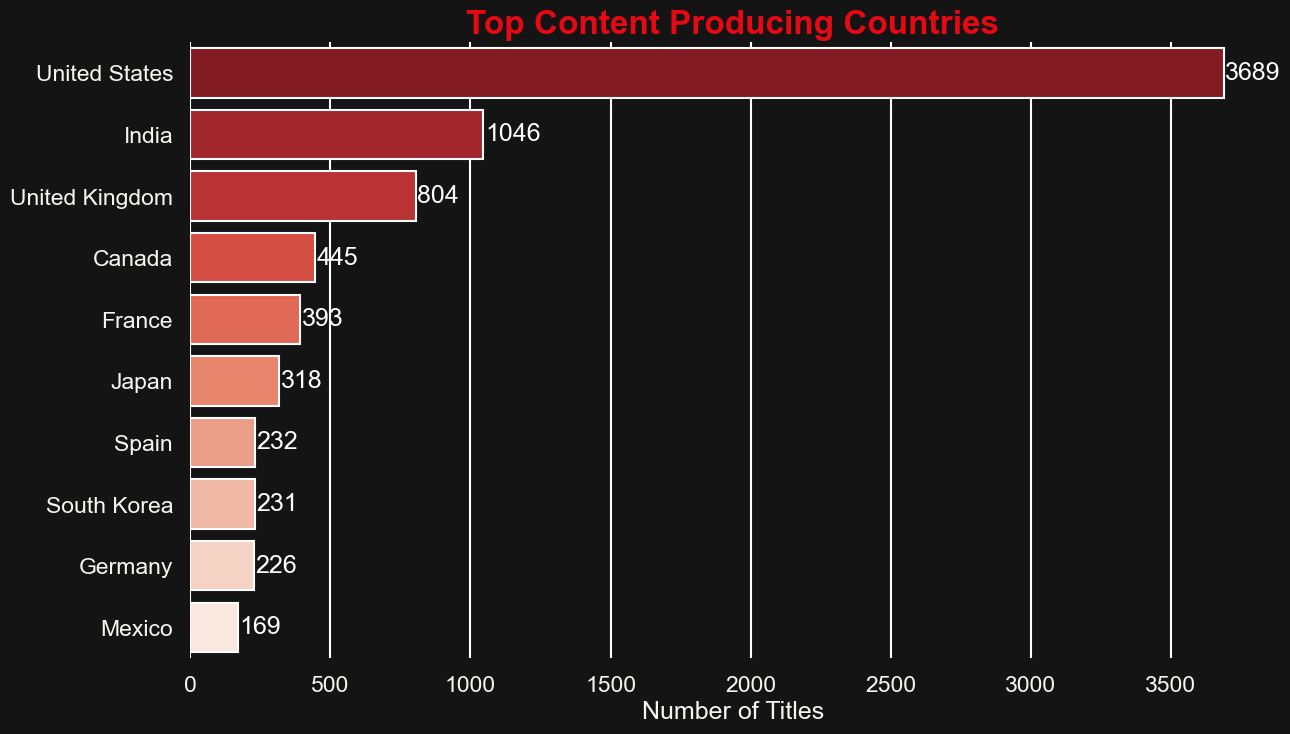

In [23]:
countries = (
    df["country"]
    .str.split(", ")
    .explode()
)

countries = countries[countries != "Unknown"]

top_countries = countries.value_counts().head(10)

plt.figure(figsize=(14,8))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette="Reds_r"
)

plt.title(
    "Top Content Producing Countries",
    fontsize=24,
    fontweight="bold",
    color=NETFLIX_RED
)

plt.xlabel("Number of Titles")
plt.ylabel("")

for i, v in enumerate(top_countries.values):
    plt.text(
        v + 5,
        i,
        str(v),
        color="white",
        va="center"
    )

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

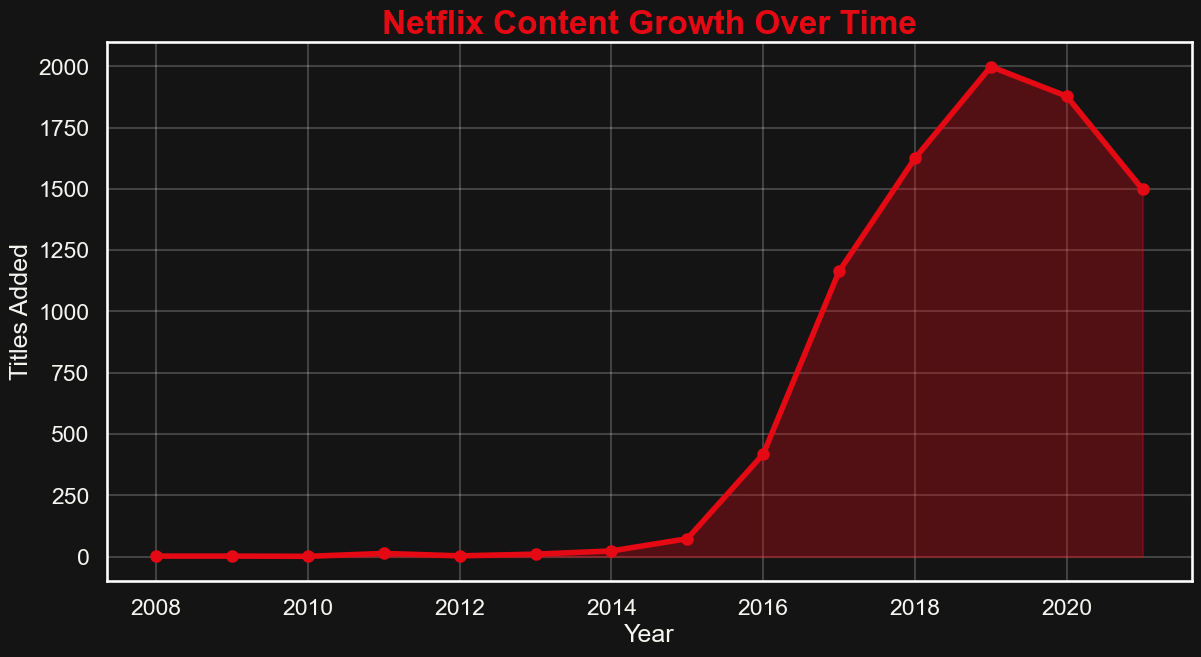

In [24]:
yearly_content = (
    df["year_added"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,7))

plt.plot(
    yearly_content.index,
    yearly_content.values,
    color=NETFLIX_RED,
    linewidth=4,
    marker="o",
    markersize=8
)

plt.fill_between(
    yearly_content.index,
    yearly_content.values,
    alpha=0.3,
    color=NETFLIX_RED
)

plt.title(
    "Netflix Content Growth Over Time",
    fontsize=24,
    fontweight="bold",
    color=NETFLIX_RED
)

plt.xlabel("Year")
plt.ylabel("Titles Added")

plt.grid(alpha=0.2)

plt.show()

C:\Users\Sarvesh Mishra\AppData\Local\Temp\ipykernel_18152\2464502584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


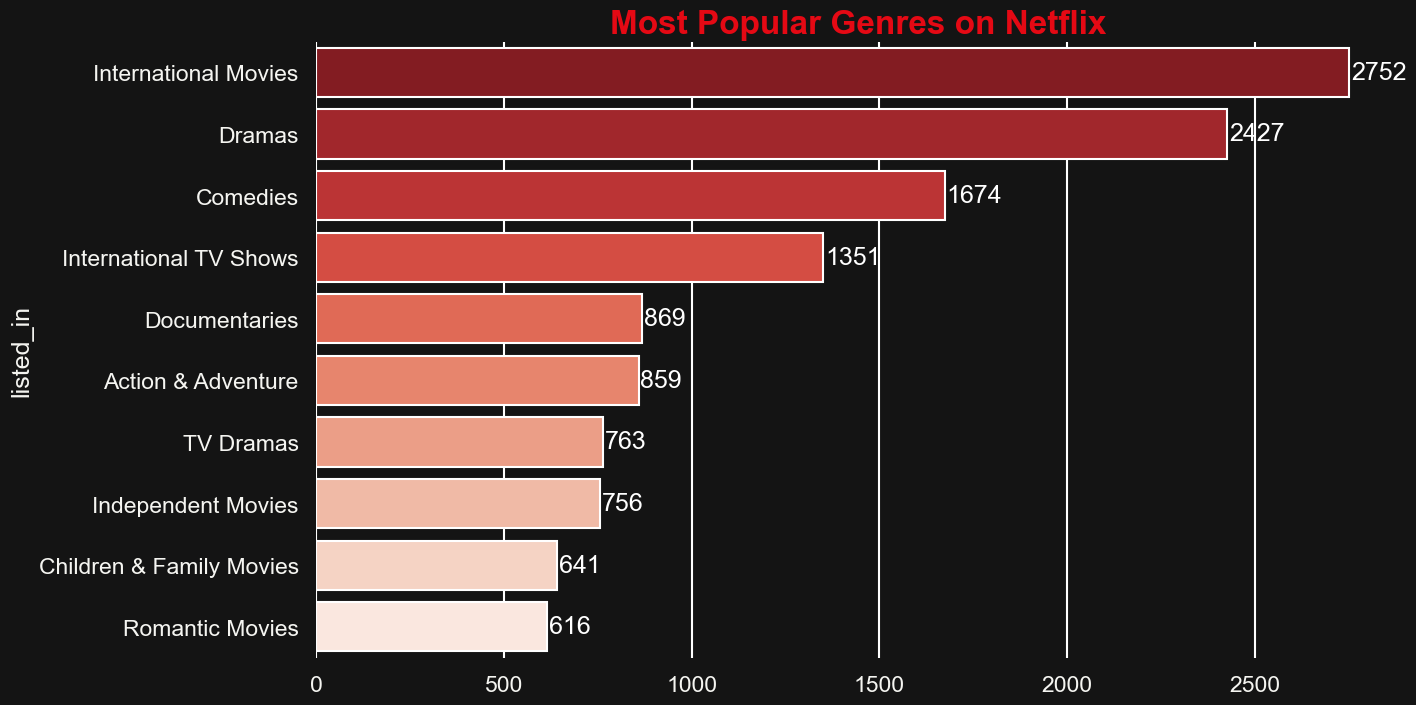

In [25]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(14,8))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette="Reds_r"
)

plt.title(
    "Most Popular Genres on Netflix",
    fontsize=24,
    fontweight="bold",
    color=NETFLIX_RED
)

for i, v in enumerate(top_genres.values):
    plt.text(
        v + 5,
        i,
        str(v),
        color="white",
        va="center"
    )

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

C:\Users\Sarvesh Mishra\AppData\Local\Temp\ipykernel_18152\436366054.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


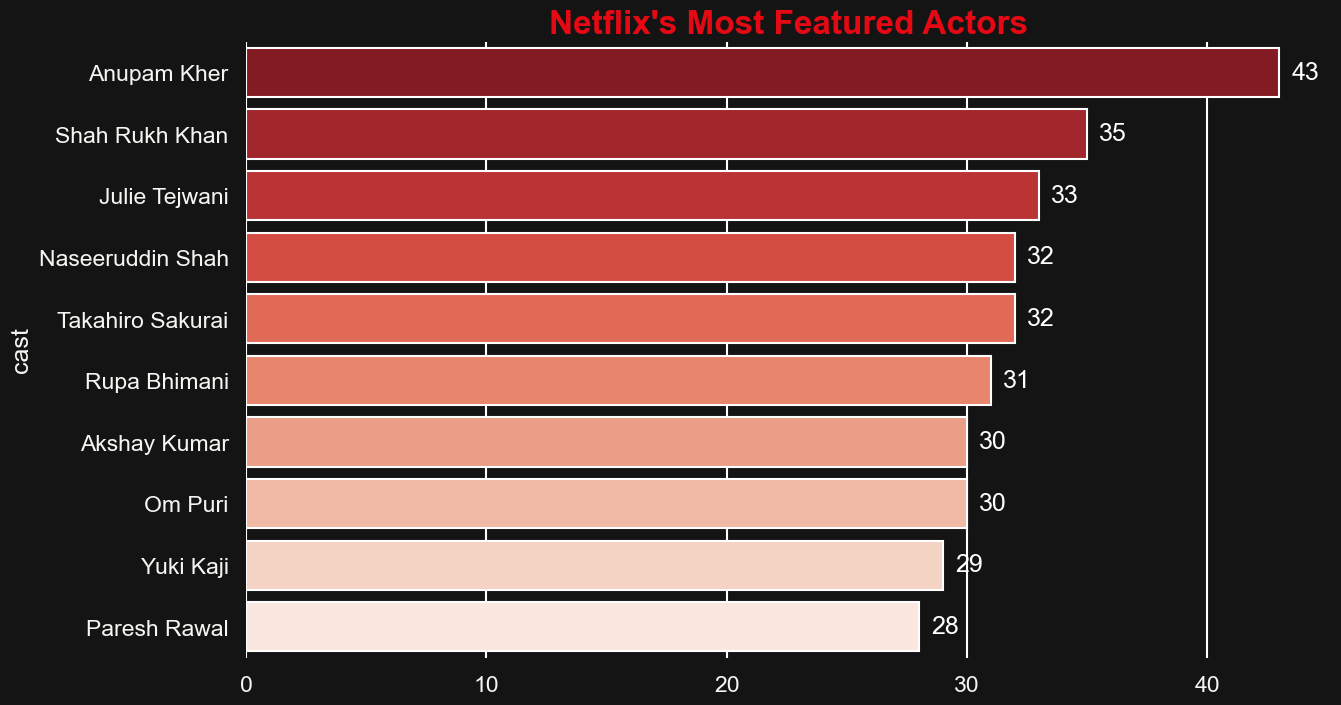

In [26]:
actors = (
    df["cast"]
    .str.split(", ")
    .explode()
)

actors = actors[actors != "Unknown"]

top_actors = actors.value_counts().head(10)

plt.figure(figsize=(14,8))

ax = sns.barplot(
    x=top_actors.values,
    y=top_actors.index,
    palette="Reds_r"
)

plt.title(
    "Netflix's Most Featured Actors",
    fontsize=24,
    fontweight="bold",
    color=NETFLIX_RED
)

for i, v in enumerate(top_actors.values):
    plt.text(
        v + 0.5,
        i,
        str(v),
        color="white",
        va="center"
    )

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

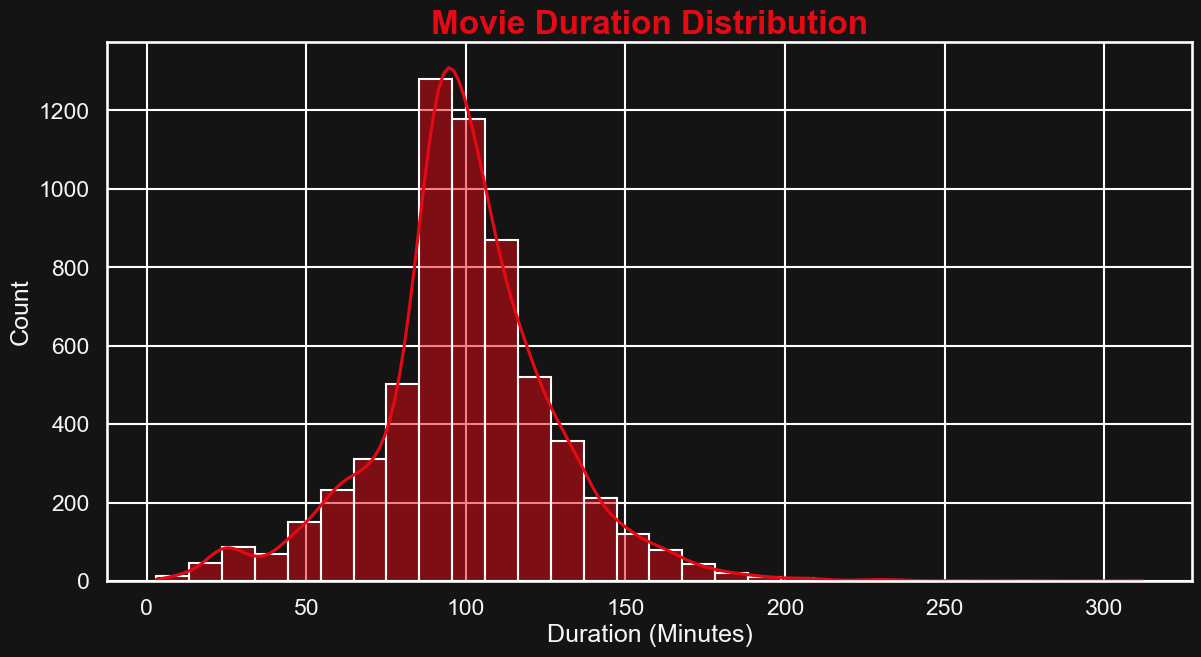

In [27]:
movies = df[df["type"] == "Movie"].copy()

movies["duration"] = (
    movies["duration"]
    .str.replace(" min", "", regex=False)
)

movies["duration"] = pd.to_numeric(
    movies["duration"],
    errors="coerce"
)

plt.figure(figsize=(14,7))

sns.histplot(
    movies["duration"],
    bins=30,
    kde=True,
    color=NETFLIX_RED
)

plt.title(
    "Movie Duration Distribution",
    fontsize=24,
    fontweight="bold",
    color=NETFLIX_RED
)

plt.xlabel("Duration (Minutes)")
plt.ylabel("Count")

plt.show()

In [28]:
total_titles = len(df)
total_movies = len(df[df["type"] == "Movie"])
total_tvshows = len(df[df["type"] == "TV Show"])

top_country = (
    df["country"]
    .str.split(", ")
    .explode()
    .replace("Unknown", pd.NA)
    .dropna()
    .value_counts()
    .idxmax()
)

top_genre = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .idxmax()
)

latest_year = int(df["release_year"].max())

print("=" * 60)
print("📺 NETFLIX CONTENT DASHBOARD")
print("=" * 60)

print(f"🎬 Total Titles      : {total_titles}")
print(f"🍿 Movies            : {total_movies}")
print(f"📺 TV Shows          : {total_tvshows}")
print(f"🌍 Top Country       : {top_country}")
print(f"🎭 Top Genre         : {top_genre}")
print(f"🆕 Latest Release Yr : {latest_year}")

print("=" * 60)

📺 NETFLIX CONTENT DASHBOARD
🎬 Total Titles      : 8807
🍿 Movies            : 6131
📺 TV Shows          : 2676
🌍 Top Country       : United States
🎭 Top Genre         : International Movies
🆕 Latest Release Yr : 2021


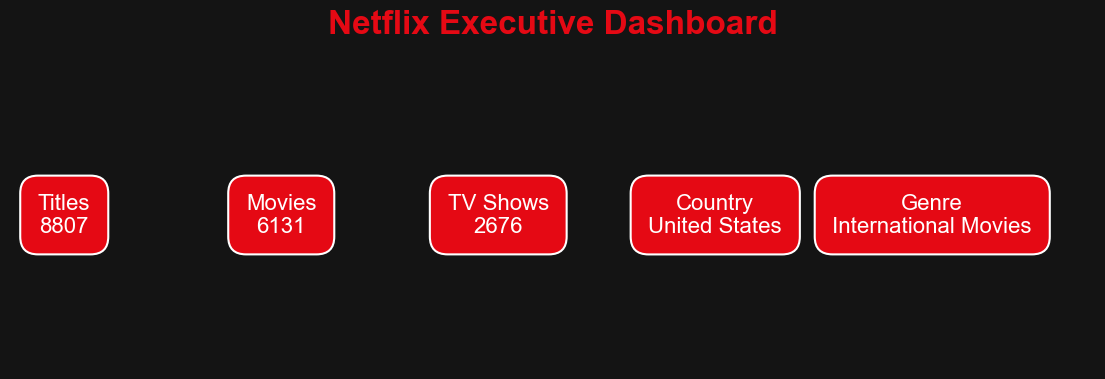

In [29]:
fig, ax = plt.subplots(figsize=(14,4))

fig.patch.set_facecolor("#141414")
ax.set_facecolor("#141414")

ax.axis("off")

cards = [
    f"Titles\n{total_titles}",
    f"Movies\n{total_movies}",
    f"TV Shows\n{total_tvshows}",
    f"Country\n{top_country}",
    f"Genre\n{top_genre}"
]

positions = [0.05, 0.25, 0.45, 0.65, 0.85]

for pos, card in zip(positions, cards):
    ax.text(
        pos,
        0.5,
        card,
        ha="center",
        va="center",
        fontsize=16,
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.8",
            facecolor="#E50914",
            edgecolor="white"
        )
    )

plt.title(
    "Netflix Executive Dashboard",
    fontsize=24,
    color="#E50914",
    fontweight="bold",
    pad=20
)

plt.show()

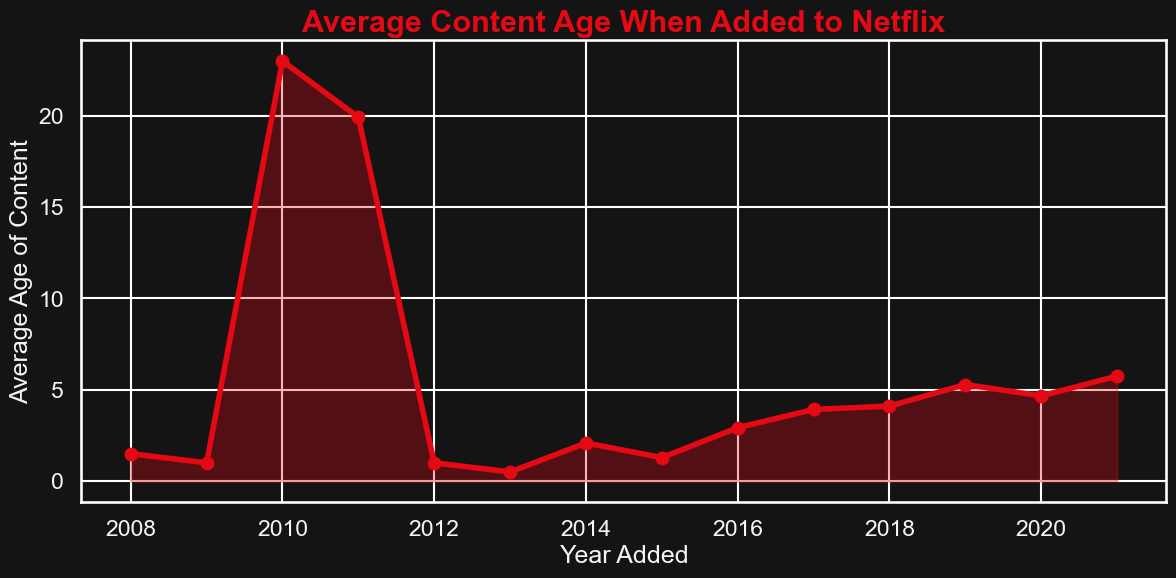

In [30]:
df["content_age_when_added"] = (
    df["year_added"] - df["release_year"]
)

freshness = (
    df.groupby("year_added")["content_age_when_added"]
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    freshness.index,
    freshness.values,
    color="#E50914",
    linewidth=4,
    marker="o"
)

plt.fill_between(
    freshness.index,
    freshness.values,
    color="#E50914",
    alpha=0.3
)

plt.title(
    "Average Content Age When Added to Netflix",
    fontsize=22,
    color="#E50914",
    fontweight="bold"
)

plt.xlabel("Year Added")
plt.ylabel("Average Age of Content")

plt.show()